In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import sparse

In [2]:
df = pd.read_csv("../data/raw/store_sales.csv")
df.head()

,date,store,sales,promo,holiday
0,2022-01-01,1,184.78,0,0
1,2022-01-02,1,192.62,0,0
2,2022-01-03,1,212.68,0,0
3,2022-01-04,1,249.58,1,0
4,2022-01-05,1,223.50,0,0


In [4]:
df = pd.read_csv("../data/raw/store_sales.csv")
n_rows = len(df)
n_products = 100
product_ids = np.tile(np.arange(1, n_products + 1), int(np.ceil(n_rows / n_products)))[:n_rows]

# Assign to dataframe
df["product_id"] = product_ids

# Save new CSV
df.to_csv("../data/raw/store_sales.csv", index=False)


In [3]:
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7300 entries, 0 to 7299
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7300 non-null   str    
 1   store    7300 non-null   int64  
 2   sales    7300 non-null   float64
 3   promo    7300 non-null   int64  
 4   holiday  7300 non-null   int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 285.3 KB


np.int64(0)

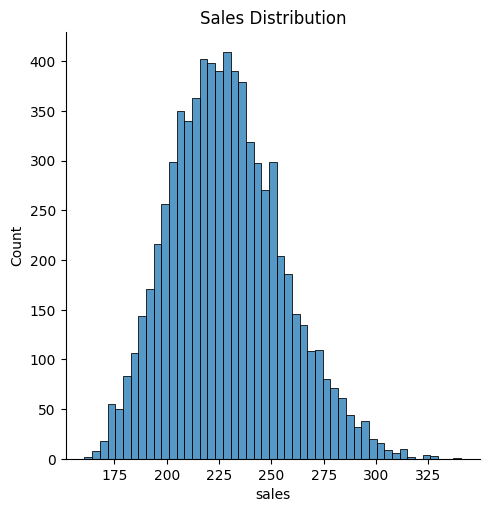

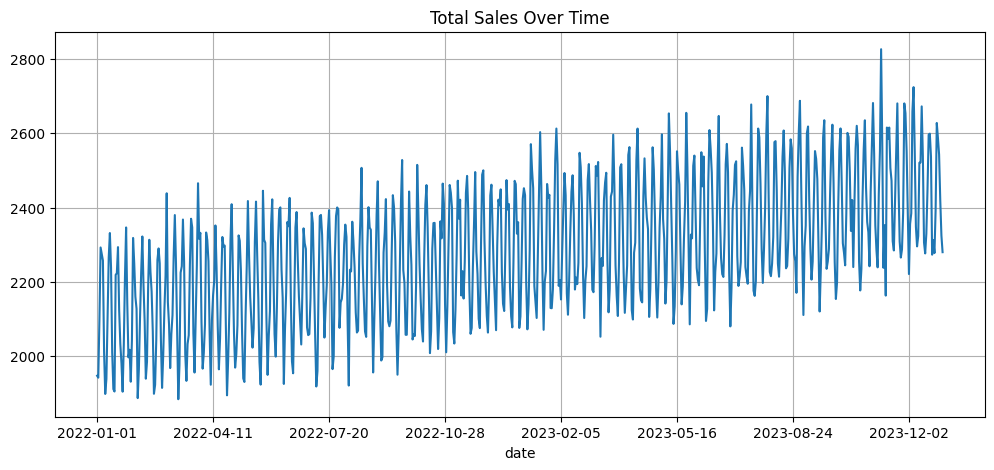

In [4]:
sns.displot(df["sales"])
plt.title("Sales Distribution")
plt.show()

df.groupby("date")["sales"].sum().plot(figsize=(12,5))
plt.title("Total Sales Over Time")
plt.grid(True)
plt.show()

In [5]:
def create_features(df):
    df = df.copy()

    df["date"] = pd.to_datetime(df["date"])

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["dayofweek"] = df["date"].dt.dayofweek
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

    df["lag_1"] = df.groupby("store")["sales"].shift(1)
    df["lag_7"] = df.groupby("store")["sales"].shift(7)
    df["lag_14"] = df.groupby("store")["sales"].shift(14)
    df["lag_21"] = df.groupby("store")["sales"].shift(21)
    df["lag_28"] = df.groupby("store")["sales"].shift(28)

    df["rolling_mean_7"] = df.groupby("store")["sales"].shift(1).rolling(7).mean()
    df["rolling_mean_14"] = df.groupby("store")["sales"].shift(1).rolling(14).mean()
    df["rolling_mean_28"] = df.groupby("store")["sales"].shift(1).rolling(28).mean()

    return df

In [6]:
df = create_features(df)
df = df.dropna()

df.head()

,date,store,sales,promo,holiday,year,month,dayofweek,is_weekend,lag_1,lag_7,lag_14,lag_21,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28
28,2022-01-29,1,225.41,0,1,2022,1,5,1,194.64,186.86,183.36,213.47,184.78,203.907143,206.882857,211.741071
29,2022-01-30,1,187.77,0,0,2022,1,6,1,225.41,183.31,185.02,222.44,192.62,209.414286,209.886429,213.192143
30,2022-01-31,1,255.73,0,1,2022,1,0,0,187.77,203.40,247.34,203.10,212.68,210.051429,210.082857,213.018929
31,2022-02-01,1,252.09,1,0,2022,2,1,0,255.73,222.36,216.91,218.78,249.58,217.527143,210.682143,214.556429
32,2022-02-02,1,220.78,0,0,2022,2,2,0,252.09,219.96,218.30,266.23,223.50,221.774286,213.195000,214.646071


In [7]:
df = df.sort_values("date")

split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print(train_df.shape, test_df.shape)

train_df["date"].min(), train_df["date"].max()
test_df["date"].min(), test_df["date"].max()

(5616, 17) (1404, 17)


(Timestamp('2023-08-13 00:00:00'), Timestamp('2023-12-31 00:00:00'))

In [8]:
train_df.to_csv("../data/processed/train.csv", index=False)
test_df.to_csv("../data/processed/test.csv", index=False)